In [ ]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.2 MB/s eta 0:00:00


In [ ]:
!pip install gensim nltk scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 82.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import re
import nltk
import gensim.downloader as api
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score
)

from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.utils import to_categorical

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Data/2. Hotel Review Dataset/Hotel_Reviews.csv")

In [ ]:
print(df.head())

print(df.columns)

print(df['Rating'].value_counts())

                                              Review  Rating
0  nice hotel expensive parking got good deal sta...       4
1  ok nothing special charge diamond member hilto...       2
2  nice rooms not 4* experience hotel monaco seat...       3
3  unique, great stay, wonderful time hotel monac...       5
4  great stay great stay, went seahawk game aweso...       5
Index(['Review', 'Rating'], dtype='object')
Rating
5    9054
4    6039
3    2184
2    1793
1    1421
Name: count, dtype: int64


In [ ]:
df['Rating'].nunique()
df['Rating'].unique()


array([4, 2, 3, 5, 1])

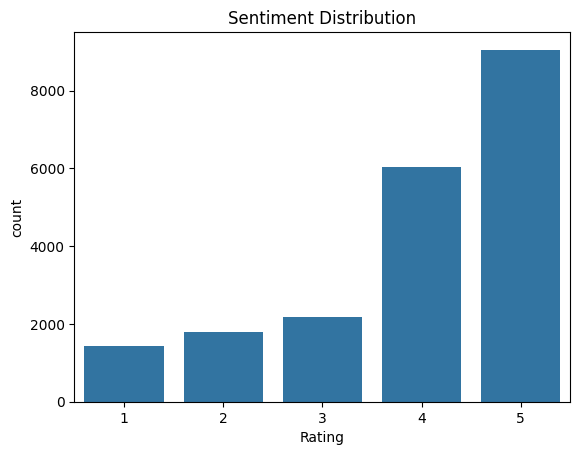

In [ ]:
sns.countplot(x=df['Rating'])

plt.title("Sentiment Distribution")

plt.show()

In [ ]:
stop_words = set(stopwords.words('english'))

# KEEP NEGATIONS
negations = {'no', 'not', 'nor', 'never'}

stop_words = stop_words - negations

lemmatizer = WordNetLemmatizer()

In [ ]:
def clean_text(text):

    text = str(text).lower()

    # keep alphabets and apostrophes
    text = re.sub(r"[^a-zA-Z\s']", " ", text)

    tokens = word_tokenize(text)

    cleaned_tokens = []

    for token in tokens:

        if token not in stop_words and len(token) > 1:

            token = lemmatizer.lemmatize(token)

            cleaned_tokens.append(token)

    return " ".join(cleaned_tokens)

In [ ]:
df['clean_review'] = df['Review'].apply(clean_text)

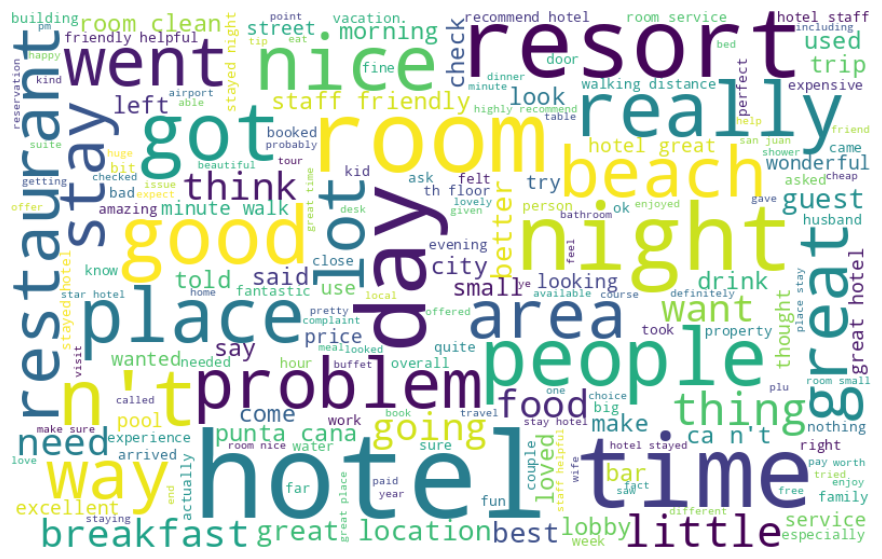

In [ ]:
from wordcloud import WordCloud

all_words = ' '.join([text for text in df['clean_review']])

# Generate the word cloud
wordcloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110, background_color='white').generate(all_words)

# Display the word cloud
plt.figure(figsize=(20, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

In [ ]:
X = df['clean_review']
y = df['Rating']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

VOCAB_SIZE = len(tokenizer.word_index) + 1
print(f"VOCAB_SIZE: {VOCAB_SIZE}")

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

train_sequence_lengths = [len(seq) for seq in X_train_seq]
MAX_LEN_95th_percentile = int(np.percentile(train_sequence_lengths, 95))

MAX_LEN = MAX_LEN_95th_percentile
print(f"MAX_LEN: {MAX_LEN}")

VOCAB_SIZE: 39877
MAX_LEN: 264


In [ ]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

In [ ]:
df['Rating'] = df['Rating'] -1



In [ ]:
df['Rating'].head(10)

,Rating
0,2
1,0
2,1
3,3
4,3
5,3
6,3
7,2
8,3
9,3


In [ ]:
NUM_CLASSES = 5

In [ ]:
y_train_cat = to_categorical(y_train - 1, NUM_CLASSES)
y_test_cat = to_categorical(y_test - 1, NUM_CLASSES)

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(2.883377308707124), 1: np.float64(2.2861924686192467), 2: np.float64(1.876588437321122), 3: np.float64(0.6786172635065204), 4: np.float64(0.45263012563854754)}


In [ ]:
import gensim.downloader as api

word2vec_model = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [ ]:
EMBED_DIM = 300

In [ ]:
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))

In [ ]:
for word, index in tokenizer.word_index.items():

    if index >= VOCAB_SIZE:
        continue

    if word in word2vec_model:

        embedding_vector = word2vec_model[word]

        embedding_matrix[index] = embedding_vector

# LSTM model with word2vec

In [ ]:
model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False,
        mask_zero=True
    ),

    LSTM(
        128,
        dropout=0.3
    ),

    Dense(64, activation='relu'),

    Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1
)

checkpoint = ModelCheckpoint(
    filepath='best_lstm_w2v_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [ ]:
lstm_w2v_model = model.fit(
    X_train_pad,
    y_train_cat,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/15
229/231 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3061 - loss: 1.4992
Epoch 1: val_loss improved from None to 1.17740, saving model to best_lstm_w2v_model.h5



Epoch 1: finished saving model to best_lstm_w2v_model.h5
231/231 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.3844 - loss: 1.3935 - val_accuracy: 0.4884 - val_loss: 1.1774 - learning_rate: 0.0010
Epoch 2/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.4226 - loss: 1.2935
Epoch 2: val_loss improved from 1.17740 to 1.06486, saving model to best_lstm_w2v_model.h5



Epoch 2: finished saving model to best_lstm_w2v_model.h5
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.4410 - loss: 1.2820 - val_accuracy: 0.5372 - val_loss: 1.0649 - learning_rate: 0.0010
Epoch 3/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4912 - loss: 1.2009
Epoch 3: val_loss did not improve from 1.06486
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.4740 - loss: 1.2156 - val_accuracy: 0.4122 - val_loss: 1.3132 - learning_rate: 0.0010
Epoch 4/15
230/231 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4744 - loss: 1.1916
Epoch 4: val_loss improved from 1.06486 to 0.99735, saving model to best_lstm_w2v_model.h5



Epoch 4: finished saving model to best_lstm_w2v_model.h5
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.4941 - loss: 1.1590 - val_accuracy: 0.5433 - val_loss: 0.9973 - learning_rate: 5.0000e-04
Epoch 5/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5302 - loss: 1.1082
Epoch 5: val_loss improved from 0.99735 to 0.98262, saving model to best_lstm_w2v_model.h5



Epoch 5: finished saving model to best_lstm_w2v_model.h5
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5324 - loss: 1.0965 - val_accuracy: 0.5524 - val_loss: 0.9826 - learning_rate: 5.0000e-04
Epoch 6/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5257 - loss: 1.0946
Epoch 6: val_loss did not improve from 0.98262
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5409 - loss: 1.0764 - val_accuracy: 0.5744 - val_loss: 0.9978 - learning_rate: 5.0000e-04
Epoch 7/15
230/231 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5560 - loss: 1.0493
Epoch 7: val_loss improved from 0.98262 to 0.90918, saving model to best_lstm_w2v_model.h5



Epoch 7: finished saving model to best_lstm_w2v_model.h5
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5544 - loss: 1.0452 - val_accuracy: 0.6006 - val_loss: 0.9092 - learning_rate: 2.5000e-04
Epoch 8/15
229/231 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5693 - loss: 1.0338
Epoch 8: val_loss did not improve from 0.90918
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.5683 - loss: 1.0248 - val_accuracy: 0.5488 - val_loss: 0.9823 - learning_rate: 2.5000e-04
Epoch 9/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5691 - loss: 1.0038
Epoch 9: val_loss improved from 0.90918 to 0.89095, saving model to best_lstm_w2v_model.h5



Epoch 9: finished saving model to best_lstm_w2v_model.h5
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5744 - loss: 0.9900 - val_accuracy: 0.6091 - val_loss: 0.8909 - learning_rate: 1.2500e-04
Epoch 10/15
229/231 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5856 - loss: 0.9693
Epoch 10: val_loss did not improve from 0.89095
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5801 - loss: 0.9844 - val_accuracy: 0.5982 - val_loss: 0.9053 - learning_rate: 1.2500e-04
Epoch 11/15
230/231 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5940 - loss: 0.9656
Epoch 11: val_loss did not improve from 0.89095
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5837 - loss: 0.9766 - val_accuracy: 0.6018 - val_loss: 0.8986 - learning_rate: 6.2500e-05
Epoch 12/15
230/231 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5920 - loss: 0.9538
Epoch 12: val_loss did not improve from 0.89095
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.5861 - loss: 0.9658 - val_accuracy: 0.59


Epoch 14: finished saving model to best_lstm_w2v_model.h5
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.5871 - loss: 0.9633 - val_accuracy: 0.6085 - val_loss: 0.8894 - learning_rate: 7.8125e-06
Epoch 15/15
229/231 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5878 - loss: 0.9663
Epoch 15: val_loss did not improve from 0.88944
231/231 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5865 - loss: 0.9701 - val_accuracy: 0.6049 - val_loss: 0.8948 - learning_rate: 7.8125e-06


In [ ]:
y_pred_probs = model.predict(X_test_pad)

y_pred = np.argmax(y_pred_probs, axis=1)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [ ]:
macro_f1 = f1_score(
    y_test,
    y_pred,
    average='macro'
)

print("Macro F1 Score:", macro_f1)

Macro F1 Score: 0.5460163648449383


In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.68      0.70      0.69       284
           1       0.41      0.48      0.44       359
           2       0.32      0.46      0.38       437
           3       0.51      0.47      0.49      1208
           4       0.77      0.69      0.73      1811

    accuracy                           0.58      4099
   macro avg       0.54      0.56      0.55      4099
weighted avg       0.61      0.58      0.59      4099



In [ ]:
cm = confusion_matrix(y_test, y_pred)

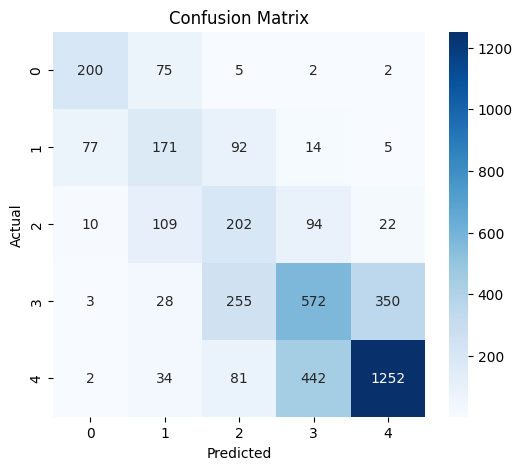

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

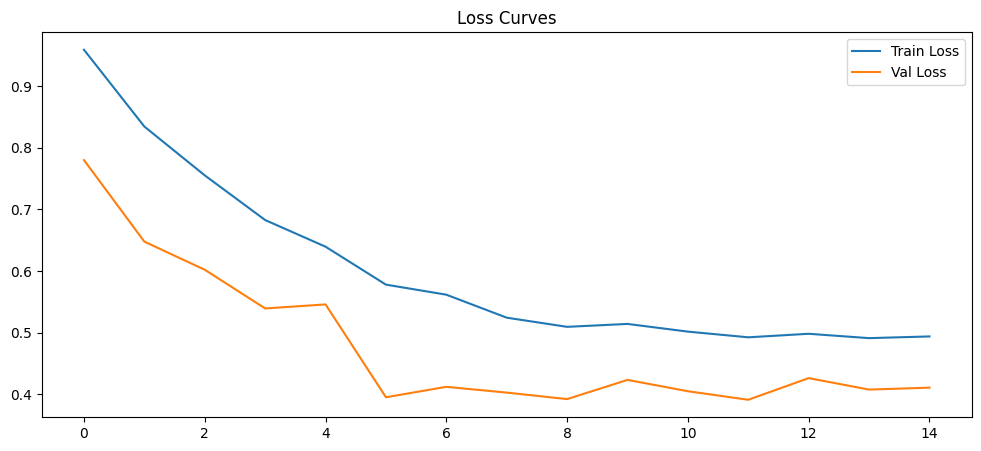

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(lstm_w2v_model.history['loss'], label='Train Loss')
plt.plot(lstm_w2v_model.history['val_loss'], label='Val Loss')

plt.legend()

plt.title("Loss Curves")

plt.show()

# RNN with Trainable Embedding Layer

In [ ]:
from tensorflow.keras.layers import SimpleRNN

In [ ]:
model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_LEN
    ),

    SimpleRNN(
        128,
        dropout=0.3,
        recurrent_dropout=0.3
    ),

    Dense(64, activation='relu'),

    Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_rnn_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [ ]:
rnn_model_simple = model.fit(

    X_train_pad,
    y_train_cat,

    validation_split=0.1,

    epochs=15,

    batch_size=64,

    class_weight=class_weights,

    callbacks=[early_stop, reduce_lr],
    verbose = 1
)

Epoch 1/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.1878 - loss: 1.7098 - val_accuracy: 0.0970 - val_loss: 1.6055 - learning_rate: 0.0010
Epoch 2/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.2088 - loss: 1.6384 - val_accuracy: 0.4457 - val_loss: 1.6091 - learning_rate: 0.0010
Epoch 3/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.2583 - loss: 1.6138 - val_accuracy: 0.4457 - val_loss: 1.5990 - learning_rate: 0.0010
Epoch 4/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.2639 - loss: 1.6126 - val_accuracy: 0.4457 - val_loss: 1.6031 - learning_rate: 0.0010
Epoch 5/15
229/231 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3577 - loss: 1.5885
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
231/231 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.2902 - loss: 1.6301 - val_accuracy: 0.0970 - val_loss: 1.6067 - learning_rate: 0.0010
Epoch 6/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.2289 - loss: 1.

In [ ]:
y_pred_probs = model.predict(X_test_pad)

y_pred = np.argmax(y_pred_probs, axis=1)

129/129 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step


In [ ]:
macro_f1 = f1_score(
    y_test,
    y_pred,
    average='macro'
)

print("Macro F1 Score:", macro_f1)

Macro F1 Score: 0.12257191201353639


In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       284
           1       0.00      0.00      0.00       359
           2       0.00      0.00      0.00       437
           3       0.00      0.00      0.00      1208
           4       0.44      1.00      0.61      1811

    accuracy                           0.44      4099
   macro avg       0.09      0.20      0.12      4099
weighted avg       0.20      0.44      0.27      4099



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
rnn_cm = confusion_matrix(y_test, y_pred)

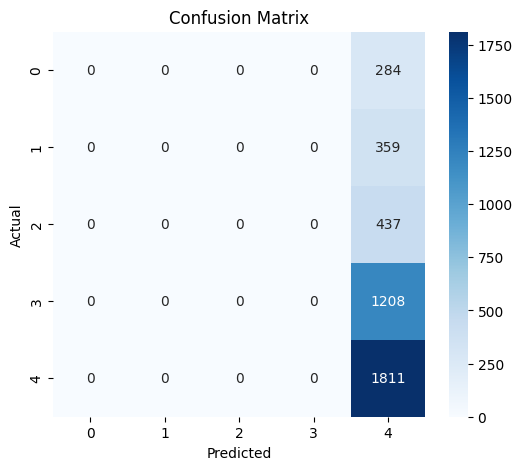

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    rnn_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

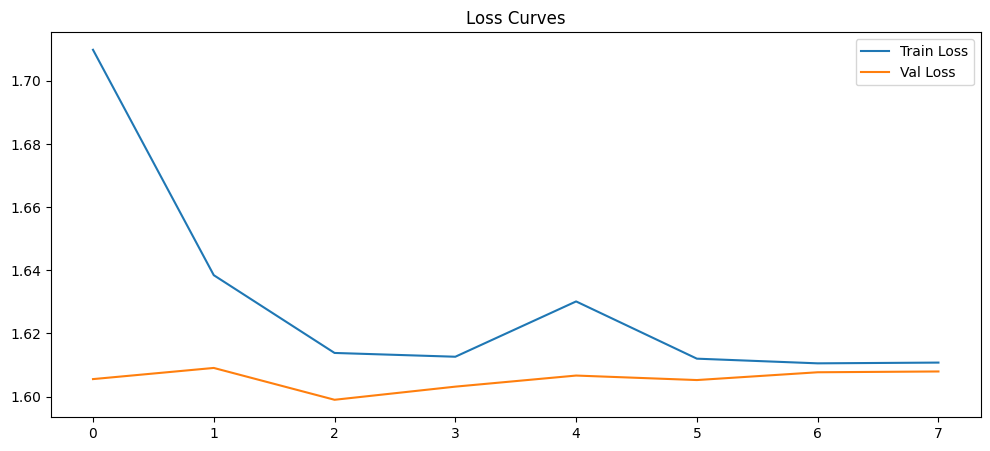

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(rnn_model_simple.history['loss'], label='Train Loss')
plt.plot(rnn_model_simple.history['val_loss'], label='Val Loss')

plt.legend()

plt.title("Loss Curves")

plt.show()

# LSTM with trainable embedding layer

In [ ]:
model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=128,
        input_length=MAX_LEN,
        mask_zero=True
    ),

    LSTM(
        128,
    ),

    Dense(64, activation='relu'),

    Dropout(0.5),

    Dense(NUM_CLASSES, activation='softmax')
])


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
lstm_trainable = model.fit(
    X_train_pad,
    y_train_cat,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],
    verbose=1
)

Epoch 1/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.2996 - loss: 1.4636
Epoch 1: val_accuracy improved from None to 0.53110, saving model to best_rnn_model.h5



Epoch 1: finished saving model to best_rnn_model.h5
231/231 ━━━━━━━━━━━━━━━━━━━━ 13s 37ms/step - accuracy: 0.3871 - loss: 1.3468 - val_accuracy: 0.5311 - val_loss: 1.0517 - learning_rate: 0.0010
Epoch 2/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5329 - loss: 1.0818
Epoch 2: val_accuracy improved from 0.53110 to 0.56037, saving model to best_rnn_model.h5



Epoch 2: finished saving model to best_rnn_model.h5
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.5483 - loss: 1.0643 - val_accuracy: 0.5604 - val_loss: 0.9824 - learning_rate: 0.0010
Epoch 3/15
230/231 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6498 - loss: 0.8215
Epoch 3: val_accuracy did not improve from 0.56037
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.6357 - loss: 0.8293 - val_accuracy: 0.5195 - val_loss: 1.0833 - learning_rate: 0.0010
Epoch 4/15
229/231 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7236 - loss: 0.6235
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_accuracy did not improve from 0.56037
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.7228 - loss: 0.6216 - val_accuracy: 0.5579 - val_loss: 1.0473 - learning_rate: 0.0010
Epoch 5/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8163 - loss: 0.3944
Epoch 5: val_accuracy did not improve from 0.56037
231/231 ━━━━━━━━━━━━━━━━━━━━ 6


Epoch 6: finished saving model to best_rnn_model.h5
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.8561 - loss: 0.3079 - val_accuracy: 0.5659 - val_loss: 1.4089 - learning_rate: 5.0000e-04
Epoch 7/15
228/231 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9118 - loss: 0.1856
Epoch 7: val_accuracy did not improve from 0.56585
231/231 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.9088 - loss: 0.1893 - val_accuracy: 0.5524 - val_loss: 1.6091 - learning_rate: 2.5000e-04
Epoch 7: early stopping
Restoring model weights from the end of the best epoch: 2.


In [ ]:
y_pred_probs = model.predict(X_test_pad)

y_pred = np.argmax(y_pred_probs, axis=1)

129/129 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [ ]:
lstm_trainable_cm = confusion_matrix(y_test, y_pred)

In [ ]:
macro_f1 = f1_score(
    y_test,
    y_pred,
    average='macro'
)

print("Macro F1 Score:", macro_f1)

Macro F1 Score: 0.5022902270041193


In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.62      0.69      0.65       284
           1       0.40      0.45      0.42       359
           2       0.27      0.36      0.31       437
           3       0.45      0.41      0.43      1208
           4       0.72      0.68      0.70      1811

    accuracy                           0.55      4099
   macro avg       0.49      0.52      0.50      4099
weighted avg       0.56      0.55      0.55      4099



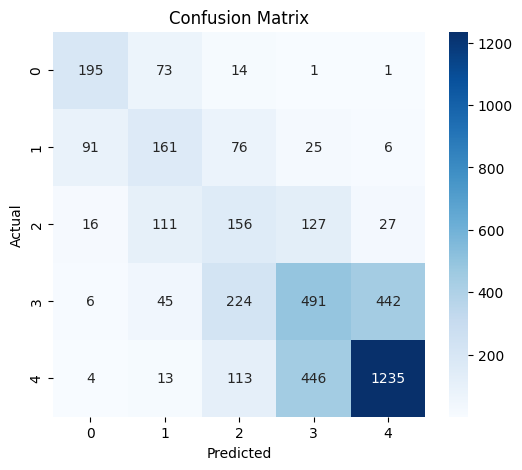

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    lstm_trainable_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

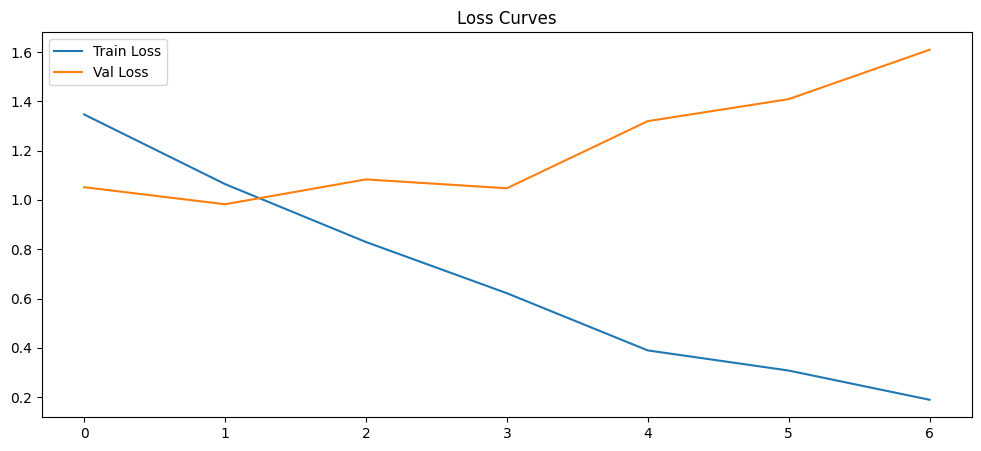

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(lstm_trainable.history['loss'], label='Train Loss')
plt.plot(lstm_trainable.history['val_loss'], label='Val Loss')

plt.legend()

plt.title("Loss Curves")

plt.show()

# Both RNN and LSTM (with and without pretrained embedding layer) failed to perform on the given dataset.

# Reducing Classes to positive and negative after some manual observation

In [ ]:
df['Rating'].value_counts()

,count
Rating,
5,9054
4,6039
3,2184
2,1793
1,1421


In [ ]:
# 0 = Negative
# 1 = Neutral
# 2 = Positive

def convert_rating(rating):
    if rating <= 3:
        return 0   # Negative
    elif rating == 4 or rating == 5:
        return 1   # Positive

df['Sentiment'] = df['Rating'].apply(convert_rating)

# Verify new classes
print(df['Sentiment'].value_counts())

Sentiment
1    15093
0     5398
Name: count, dtype: int64


In [ ]:
X = df['clean_review']
y = df['Sentiment']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding='post',
    truncating='post'
)

In [ ]:
y_train_cat = to_categorical(y_train, 2)
y_test_cat = to_categorical(y_test, 2)

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.8981009726725335), 1: np.float64(0.6788139804538678)}


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1
)

checkpoint = ModelCheckpoint(
    filepath='best_binary_class_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Bidirectional, Dense, Dropout

model = Sequential([

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False,
        mask_zero=True
    ),

    Bidirectional(
        LSTM(
            128,
            dropout=0.3
        )
    ),

    Dense(64, activation='relu'),

    Dropout(0.5),

    Dense(2, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
binary_w2v_bilstm_model = model.fit(
    X_train_pad,
    y_train_cat,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7550 - loss: 0.4871
Epoch 1: val_loss did not improve from 0.28268
231/231 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.8146 - loss: 0.4078 - val_accuracy: 0.8659 - val_loss: 0.3182 - learning_rate: 0.0010
Epoch 2/15
230/231 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8589 - loss: 0.3209
Epoch 2: val_loss did not improve from 0.28268
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.8675 - loss: 0.3075 - val_accuracy: 0.8768 - val_loss: 0.2922 - learning_rate: 5.0000e-04
Epoch 3/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8812 - loss: 0.2857
Epoch 3: val_loss did not improve from 0.28268
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.8778 - loss: 0.2875 - val_accuracy: 0.8689 - val_loss: 0.3019 - learning_rate: 2.5000e-04
Epoch 4/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8825 - loss: 0.2767
Epoch 4: val_loss improved from 0.28268 to 0.27377, saving model to best_bin


Epoch 4: finished saving model to best_binary_class_model.h5
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - accuracy: 0.8839 - loss: 0.2764 - val_accuracy: 0.8835 - val_loss: 0.2738 - learning_rate: 1.2500e-04
Epoch 5/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.8858 - loss: 0.2665
Epoch 5: val_loss did not improve from 0.27377
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.8833 - loss: 0.2695 - val_accuracy: 0.8805 - val_loss: 0.2868 - learning_rate: 1.2500e-04
Epoch 6/15
230/231 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8890 - loss: 0.2634
Epoch 6: val_loss did not improve from 0.27377
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.8890 - loss: 0.2625 - val_accuracy: 0.8872 - val_loss: 0.2747 - learning_rate: 6.2500e-05
Epoch 7/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8801 - loss: 0.2694
Epoch 7: val_loss did not improve from 0.27377
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.8873 - loss: 0.2630 - val_accuracy: 0.8835


Epoch 9: finished saving model to best_binary_class_model.h5
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 35ms/step - accuracy: 0.8917 - loss: 0.2542 - val_accuracy: 0.8841 - val_loss: 0.2728 - learning_rate: 7.8125e-06
Epoch 10/15
229/231 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8934 - loss: 0.2526
Epoch 10: val_loss did not improve from 0.27278
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.8934 - loss: 0.2532 - val_accuracy: 0.8848 - val_loss: 0.2747 - learning_rate: 7.8125e-06
Epoch 11/15
231/231 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8924 - loss: 0.2461
Epoch 11: val_loss did not improve from 0.27278
231/231 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.8909 - loss: 0.2538 - val_accuracy: 0.8854 - val_loss: 0.2733 - learning_rate: 3.9063e-06
Epoch 12/15
230/231 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8935 - loss: 0.2480
Epoch 12: val_loss did not improve from 0.27278
231/231 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.8910 - loss: 0.2541 - val_accuracy: 

In [ ]:
y_pred_probs = model.predict(X_test_pad)

y_pred = (y_pred_probs > 0.5).astype(int)

129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step


In [ ]:
macro_f1 = f1_score(
    y_test,
    y_pred,
    average='macro'
)

print("Macro F1 Score:", macro_f1)

Macro F1 Score: 0.8493950922947633


In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.73      0.85      0.78      1080
           1       0.94      0.89      0.91      3019

    accuracy                           0.88      4099
   macro avg       0.84      0.87      0.85      4099
weighted avg       0.89      0.88      0.88      4099



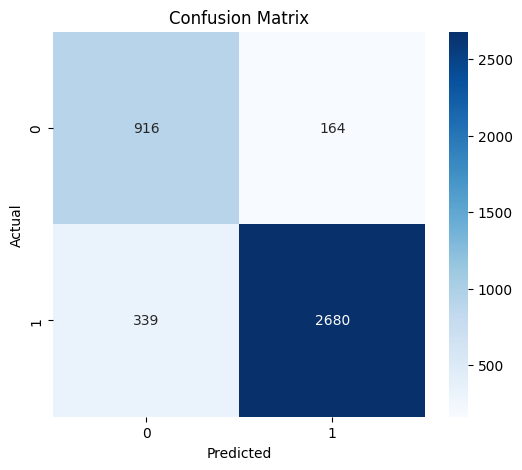

In [ ]:
final_cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

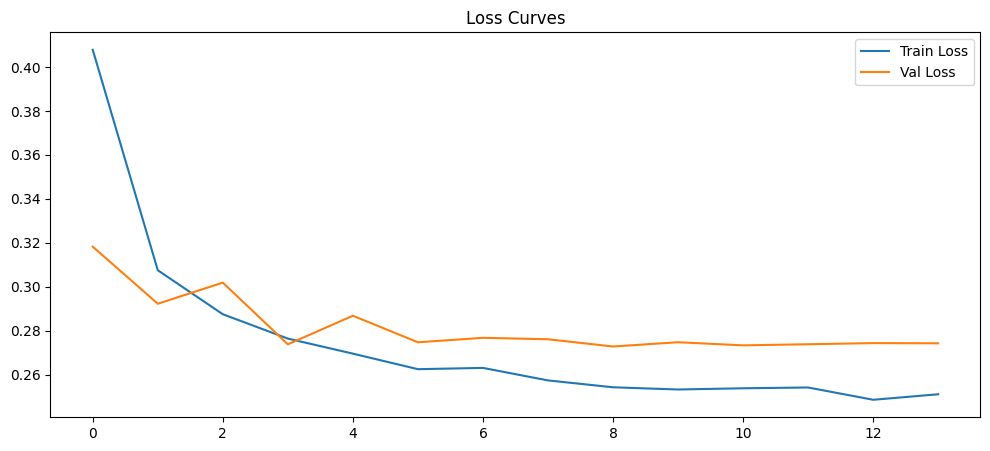

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(binary_w2v_bilstm_model.history['loss'], label='Train Loss')
plt.plot(binary_w2v_bilstm_model.history['val_loss'], label='Val Loss')

plt.legend()

plt.title("Loss Curves")

plt.show()